# Rust
Las ventajas de Rust frente a Python incluyen su mayor rendimiento y seguridad de memoria 
gracias a su sistema de gestión de propiedad y ausencia de recolector de basura, lo que lo 
hace ideal para aplicaciones de bajo nivel y de alta velocidad. 

Además, Rust ofrece soporte nativo para la concurrencia sin las limitaciones de los lenguajes 
interpretados, evitando las carreras de datos y permitiendo un paralelismo robusto. 

# Rust : crear entorno de desarrollo. 

Consultar el fichero que indica los pasos: https://mega.nz/file/9qtiwb7L#_JpzIJlvBkoJch6EoSELK4cx5zAP2Gqk_yY1PpRZu7Q

# Instalación Rust en Jupyter Notebook linux:

** Es un resumen del fichero de creación del entorno anterior cuya url se indica arriba**

Instalar Rust en WSL2 con Ubuntu, y luego usarlo en Jupyter Notebook dentro de VS Code, implica varios pasos.

**Paso 1: Instalar Rust en WSL2 (Ubuntu):**  

Desde el terminal y dentro del entorno de trabajo de Rus, ejecuto: 

    - $curl --proto '=https' --tlsv1.2 -sSf https://sh.rustup.rs | sh
  
    - $rustc --version

    - $cargo --version

**Paso 2: Instalar el kernel de Jupyter para Rust**

    - $sudo apt install libzmq3-dev

    - $cargo install evcxr_jupyter

Este último paso puede tardar un poco ya que compila el kernel desde la fuente.

    - $~/.cargo/bin/evcxr_jupyter --install
  
Verificamos que se haya instalado consultando los kernels

    - jupyter kernelspec list

<img src="./images/rustkernel.PNG" />

# Extensiónes recomendadas

    -	$ code --install-extension ms-python.python <-- integra python y conda

    -	$ code --install-extension ms-toolsai.jupyter <-- permite usar notebook con ese python

    -	$ code --install-extension rust-lang.rust-analyzer <-- autocompletado, diagnóstico y ejecución de rust


# Seleccionamos el kernel de Rust

**Seleccionar kernel --> kernel de jupyter ---> rust**

In [ ]:
println!("¡Hola desde Rust en Jupyter!");

¡Hola desde Rust en Jupyter!


# Ejemplo de programa cuántico en Rust puro: 

Un estado de bell

In [ ]:

// :dep permite añadir dependencias en tiempo de ejecución
:dep ndarray = "0.15"
:dep num-complex = "0.4"

use ndarray::{Array1, Array2};
use num_complex::Complex;

const SQRT2_INV: f64 = 0.70710678118;

let mut state: Array1<Complex<f64>> = Array1::from_vec(vec![
    Complex::new(1.0, 0.0),
    Complex::new(0.0, 0.0),
    Complex::new(0.0, 0.0),
    Complex::new(0.0, 0.0),
]);

let h_i: Array2<Complex<f64>> = Array2::from_shape_vec((4, 4), vec![
    Complex::new(SQRT2_INV, 0.0), Complex::new(0.0, 0.0), Complex::new(SQRT2_INV, 0.0), Complex::new(0.0, 0.0),
    Complex::new(0.0, 0.0), Complex::new(SQRT2_INV, 0.0), Complex::new(0.0, 0.0), Complex::new(SQRT2_INV, 0.0),
    Complex::new(SQRT2_INV, 0.0), Complex::new(0.0, 0.0), Complex::new(-SQRT2_INV, 0.0), Complex::new(0.0, 0.0),
    Complex::new(0.0, 0.0), Complex::new(SQRT2_INV, 0.0), Complex::new(0.0, 0.0), Complex::new(-SQRT2_INV, 0.0),
]).unwrap();

state = h_i.dot(&state);

let cnot: Array2<Complex<f64>> = Array2::from_shape_vec((4, 4), vec![
    Complex::new(1.0, 0.0), Complex::new(0.0, 0.0), Complex::new(0.0, 0.0), Complex::new(0.0, 0.0),
    Complex::new(0.0, 0.0), Complex::new(1.0, 0.0), Complex::new(0.0, 0.0), Complex::new(0.0, 0.0),
    Complex::new(0.0, 0.0), Complex::new(0.0, 0.0), Complex::new(0.0, 0.0), Complex::new(1.0, 0.0),
    Complex::new(0.0, 0.0), Complex::new(0.0, 0.0), Complex::new(1.0, 0.0), Complex::new(0.0, 0.0),
]).unwrap();

state = cnot.dot(&state);

println!("Estado de Bell |Φ⁺⟩:");
for (i, amp) in state.iter().enumerate() {
    let basis = format!("{:02b}", i);
    println!("|{}⟩: {:.4} + {:.4}i", basis, amp.re, amp.im);
}

println!("\nProbabilidades:");
for (i, amp) in state.iter().enumerate() {
    let prob = (amp.re * amp.re + amp.im * amp.im).round();
    if prob > 0.0 {
        let basis = format!("{:02b}", i);
        println!("P(|{}⟩) = {:.0}%", basis, prob * 100.0);
    }
}

Estado de Bell |Φ⁺⟩:
|00⟩: 0.7071 + 0.0000i
|01⟩: 0.0000 + 0.0000i
|10⟩: 0.0000 + 0.0000i
|11⟩: 0.7071 + 0.0000i

Probabilidades:


()

# Estado de bell en línea de comandos creando proyecto con cargo

El proyecto se crea en línea de comandos y se compila y ejecuta en línea  de comandos. No necesito seleccionar ningún kernel de VSCode.

Crear un programa Rust que:

    - Represente 2 qubits.

    - Aplique una puerta Hadamard y una CNOT.

    - Genere el estado de Bell ∣Φ + ⟩= 1/sqrt(2)(∣00⟩+∣11⟩) .

    - Imprima amplitudes y probabilidades.

#### Paso 1: Crear el proyecto con la herramienta cargo

Abrimos la terminal en WSL2 (Ubuntu) dentro de nuestra carpeta pruebasRust y ejecutamos:

    - $cargo new bell_state_simulator

    - $cd bell_state_simulator

#### Paso 2: Agregamos dependencias

Accedemos al directorio bell_state_simulator. Editamos el archivo Cargo.toml. 

Añadimos las bibliotecas necesarias para cálculos numéricos y números complejos para que quede así: 

    [package]

    name = "bell_state_simulator"

    version = "0.1.0"

    edition = "2024"

    [dependencies]

    ndarray = "0.15"

    num-complex = "0.4"

#### Paso 3: Escribir el código en src/main.rs

Dentro de bell_state_simulator, entro en src y edito main.rs. Borro si contenido y copio el siguiente:

In [ ]:
use ndarray::{Array1, Array2};
use num_complex::Complex;

const INV_SQRT_2: f64 = 0.7071067811865476; // 1 / √2

fn main() {
    // Estado inicial |00⟩ → [1, 0, 0, 0]
    let mut state: Array1<Complex<f64>> = Array1::from_vec(vec![
        Complex::new(1.0, 0.0),
        Complex::new(0.0, 0.0),
        Complex::new(0.0, 0.0),
        Complex::new(0.0, 0.0),
    ]);

    // Puerta Hadamard en el primer qubit: H ⊗ I
    let h_i: Array2<Complex<f64>> = Array2::from_shape_vec(
        (4, 4),
        vec![
            Complex::new(INV_SQRT_2, 0.0), Complex::new(0.0, 0.0), Complex::new(INV_SQRT_2, 0.0), Complex::new(0.0, 0.0),
            Complex::new(0.0, 0.0), Complex::new(INV_SQRT_2, 0.0), Complex::new(0.0, 0.0), Complex::new(INV_SQRT_2, 0.0),
            Complex::new(INV_SQRT_2, 0.0), Complex::new(0.0, 0.0), Complex::new(-INV_SQRT_2, 0.0), Complex::new(0.0, 0.0),
            Complex::new(0.0, 0.0), Complex::new(INV_SQRT_2, 0.0), Complex::new(0.0, 0.0), Complex::new(-INV_SQRT_2, 0.0),
        ],
    ).expect("Error al crear H ⊗ I");

    state = h_i.dot(&state);

    // Puerta CNOT (control = qubit 0, target = qubit 1)
    let cnot: Array2<Complex<f64>> = Array2::from_shape_vec(
        (4, 4),
        vec![
            Complex::new(1.0, 0.0), Complex::new(0.0, 0.0), Complex::new(0.0, 0.0), Complex::new(0.0, 0.0),
            Complex::new(0.0, 0.0), Complex::new(1.0, 0.0), Complex::new(0.0, 0.0), Complex::new(0.0, 0.0),
            Complex::new(0.0, 0.0), Complex::new(0.0, 0.0), Complex::new(0.0, 0.0), Complex::new(1.0, 0.0),
            Complex::new(0.0, 0.0), Complex::new(0.0, 0.0), Complex::new(1.0, 0.0), Complex::new(0.0, 0.0),
        ],
    ).expect("Error al crear CNOT");

    state = cnot.dot(&state);

    // Mostrar el estado cuántico resultante
    println!("✅ Estado de Bell |Φ⁺⟩ = 1/√2 (|00⟩ + |11⟩)");
    println!("\nAmplitudes:");
    for (i, amplitude) in state.iter().enumerate() {
        let basis = format!("{:02b}", i);
        println!("|{}⟩: {:.6} + {:.6}i", basis, amplitude.re, amplitude.im);
    }

    println!("\nProbabilidades:");
    for (i, amplitude) in state.iter().enumerate() {
        let prob = amplitude.norm_sqr(); // |a|² + |b|²
        if prob > 1e-10 {
            let basis = format!("{:02b}", i);
            println!("P(|{}⟩) = {:.2}%", basis, prob * 100.0);
        }
    }
}

#### Paso 4: Compilar y ejecutar

En la terminal, dentro de la carpeta del proyecto (bell_state_simulator), ejecuta:

    - $ cargo run
  

El resultado en la línea de comandos es: 

<img src="./images/ejecucionBellRustLineaComandos.PNG" />

**Este ejercicio se ha ejecutado con un simulador básico de dos qubits**

# Creación del proyecto con cargo y ejecución en jupyter notebook

#### Paso 1: Instalar dependencias del sistema (en WSL2 Ubuntu)

Para utilizar el simulador qsim necesitamos un compilador C++ y cmake porque incluye código nativo:

    - $sudo apt update

    - $sudo apt install build-essential cmake

#### Paso 2: Crear el proyecto con cargo

    - $cargo new bell_cli
  
    - $cd bell_cli

#### Paso 3: Agregamos el simulador qsim como dependencia


Edito Cargo.toml y lo dejo escrito de esta forma:

    [package]

    name = "bell_cli"

    version = "0.1.0"

    edition = "2021"

    [dependencies]

    serde = { version = "1.0", features = ["derive"] }

    serde_json = "1.0"

    num-complex = "0.4"

#### Paso 4: Escribir el código en src/main.rs

Entro en el directorio bell_cli y en src y edito main.rs. Borro su contenido y lo relleno con el siguiente código:


In [ ]:
use num_complex::Complex;
use serde::Serialize;
use std::f64::consts::FRAC_1_SQRT_2;
use std::fs::File;
use std::io::Write;

#[derive(Serialize)]
struct Resultado {
    amplitudes: Vec<(String, f64, f64)>, // (basis, re, im)
    probabilidades: Vec<(String, f64)>,  // (basis, prob)
}

fn main() {
    // Estado inicial |00⟩
    let mut state = [
        Complex::new(1.0, 0.0),
        Complex::new(0.0, 0.0),
        Complex::new(0.0, 0.0),
        Complex::new(0.0, 0.0),
    ];

    // H ⊗ I
    let h_i = [
        [FRAC_1_SQRT_2, 0.0, FRAC_1_SQRT_2, 0.0],
        [0.0, FRAC_1_SQRT_2, 0.0, FRAC_1_SQRT_2],
        [FRAC_1_SQRT_2, 0.0, -FRAC_1_SQRT_2, 0.0],
        [0.0, FRAC_1_SQRT_2, 0.0, -FRAC_1_SQRT_2],
    ];

    let mut new_state = [Complex::new(0.0, 0.0); 4];
    for i in 0..4 {
        for j in 0..4 {
            new_state[i] += Complex::new(h_i[i][j], 0.0) * state[j];
        }
    }
    state = new_state;

    // CNOT
    let cnot = [
        [1.0, 0.0, 0.0, 0.0],
        [0.0, 1.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 1.0],
        [0.0, 0.0, 1.0, 0.0],
    ];

    let mut new_state = [Complex::new(0.0, 0.0); 4];
    for i in 0..4 {
        for j in 0..4 {
            new_state[i] += Complex::new(cnot[i][j], 0.0) * state[j];
        }
    }
    state = new_state;

    // Preparar resultados
    let mut amplitudes = Vec::new();
    let mut probabilidades = Vec::new();

    for (i, amp) in state.iter().enumerate() {
        let basis = format!("{:02b}", i);
        amplitudes.push((basis.clone(), amp.re, amp.im));
        let prob = amp.norm_sqr();
        if prob > 1e-10 {
            probabilidades.push((basis, prob));
        }
    }

    let resultado = Resultado {
        amplitudes,
        probabilidades,
    };

    // Guardar en JSON
    let json = serde_json::to_string_pretty(&resultado).unwrap();
    let mut file = File::create("bell_result.json").unwrap();
    file.write_all(json.as_bytes()).unwrap();

    println!("✅ Resultados guardados en bell_result.json");
}

#### Paso 5: Compilar y ejecutar y crear un json.

Desde dentro del directorio del proyecto

    - $cargo run --release


#### Paso5: Ejecuto con kernell python

**Cargo kernel CondaCodingRustEnvironment**

In [ ]:
%pip install matplotlib

Compilando y ejecutando simulación en Rust...
✅ Simulación completada. Leyendo resultados...
json_pahth: ./bell_cli/bell_result.json

Amplitudes:
|00⟩: 0.707107 + 0.000000i
|01⟩: 0.000000 + 0.000000i
|10⟩: 0.000000 + 0.000000i
|11⟩: 0.707107 + 0.000000i

Probabilidades:
P(|00⟩) = 50.0%
P(|11⟩) = 50.0%


Text(0.5, 1.0, 'Probabilidades de los estados de Bell')

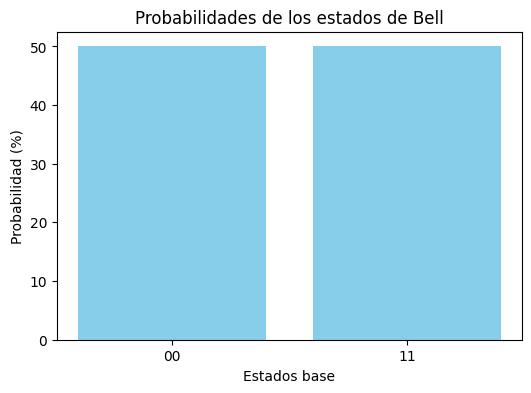

In [3]:
import subprocess
import os
import json
import matplotlib.pyplot as plt

# Ruta absoluta a cargo (ajusta "miguel" por tu usuario)
CARGO_PATH = "/home/miguel/.cargo/bin/cargo"
RUST_PROJECT_DIR = "./bell_cli"

print("Compilando y ejecutando simulación en Rust...")
result = subprocess.run(
    [CARGO_PATH, "run", "--release"],
    cwd=RUST_PROJECT_DIR,
    capture_output=True,
    text=True
)

if result.returncode != 0:
    print("❌ Error al ejecutar Rust:")
    print(result.stderr)
    raise RuntimeError("Falló la simulación en Rust")

print("✅ Simulación completada. Leyendo resultados...")

# El JSON se guarda DENTRO de bell_cli/
json_path = os.path.join(RUST_PROJECT_DIR, "bell_result.json")

print("json_pahth:", json_path)

if not os.path.exists(json_path):
    raise FileNotFoundError(f"No se encontró {json_path}. ¿Se ejecutó correctamente el programa Rust?")

# Cargar y mostrar
with open(json_path, "r") as f:
    data = json.load(f)

# Mostrar resultados
print("\nAmplitudes:")
for basis, re, im in data["amplitudes"]:
    print(f"|{basis}⟩: {re:.6f} + {im:.6f}i")

print("\nProbabilidades:")
labels = []
probs = []
for basis, prob in data["probabilidades"]:
    print(f"P(|{basis}⟩) = {prob*100:.1f}%")
    labels.append(basis)
    probs.append(prob)

# Gráfico de barras
plt.figure(figsize=(6,4))
plt.bar(labels, [p*100 for p in probs], color='skyblue')
plt.xlabel('Estados base')
plt.ylabel('Probabilidad (%)')
plt.title('Probabilidades de los estados de Bell')      

# Ejecución de un programa Rust en celda mágica jupyter notebook con kernel python 

No funciona, el proyecto se ha abandonado. 
 